In [288]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from osgeo import gdal
import xarray as xr
from scipy.io import loadmat

In [433]:
def get_prediction(A,gamma,g,d,rhos,rhof):
    return (A*(rhos/rhof*g*d+gamma/rhof/d))**0.5

def get_loss(params_fit,u_data,g,d,rhos,rhof):
    A,gamma = params_fit
    u_pred = get_prediction(A,gamma,g,d,rhos,rhof)
    return u_data/u_pred-1

def get_r2(x,y):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    return 1-np.sum(residuals**2)/np.sum((y-np.mean(y))**2)

def get_r2(x,y):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    return 1-np.sum(residuals**2)/np.sum((y-np.mean(y))**2)

def get_percentiles(x):
    y_percentiles = np.arange(101)
    x_percentiles = np.percentile(x,y_percentiles)
    return x_percentiles,y_percentiles

def get_realpdf(x,y,nbins):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted    
    bins    = np.linspace(-np.max(np.abs(residuals)),np.max(np.abs(residuals)),nbins)
    binmids = bins[1:] - np.diff(bins)/2
    bindensity,_ = np.histogram(residuals,bins=bins,density=True)
    return bindensity,binmids,bins

def get_normalpdf(x,y,binmids):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    mean = np.mean(residuals)
    std = np.std(residuals)
    return stats.norm.pdf(binmids,mean,std)

def get_powerlaw_constants(x,y):
    polyfit = np.polyfit(np.log10(x),np.log10(y),1)
    l,n = 10**polyfit[1],polyfit[0]
    return l,n

def parascatter(df,xs,ys,xerrs=None,yerrs=None,size=3,
                s=None,lw=None,color=None,scale='linear',wspace=0.3,hspace=0.4):
    plt.figure(figsize=(len(ys)*size,len(xs)*size))
    #size is how many rows by coloumns
    for i in range(len(xs)): #creating the loop.Len(xs) is how many rows do we want
        for j in range(len(ys)): #the Len(xs) is how many coloumns do we want
            plt.subplot(len(xs),len(ys),j+i*len(ys)+1)
            plt.scatter(df[xs[i]],df[ys[j]],
                        s=s,color=color,lw=lw)
            if xerrs:
                plt.plot([df[xs[i]]-df[xerrs[i]],df[xs[i]]+df[xerrs[i]]],
                         [df[ys[j]],df[ys[j]]],
                         color=color,lw=lw)
            if yerrs:
                plt.plot([df[xs[i]],df[xs[i]]],
                         [df[ys[j]]-df[yerrs[j]],df[ys[j]]+df[yerrs[j]]],
                         color=color,lw=lw)
            plt.xscale(scale)
            plt.yscale(scale)
            plt.xlabel(xs[i])
            plt.ylabel(ys[j])
    plt.subplots_adjust(wspace=wspace,hspace=hspace)

def get_prediction(A,gamma,g,d,rhos,rhof): #change to correct variables and correct equation 
    return (A*(rhos/rhof*g*d+gamma/rhof/d))**0.5
    
def get_loss(params_fit,u_data,g,d,rhos,rhof):
    A,gamma = params_fit
    u_pred = get_prediction(A,gamma,g,d,rhos,rhof)
    return u_data/u_pred-1

def get_r2(x,y):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    return 1-np.sum(residuals**2)/np.sum((y-np.mean(y))**2)

In [523]:
data = pd.read_csv("Microbe_Analysis_Data.csv")

In [513]:
df = data 
df0 = data

Text(0.5, 1.0, 'Fo diffusion for sample SHIV-08-05')

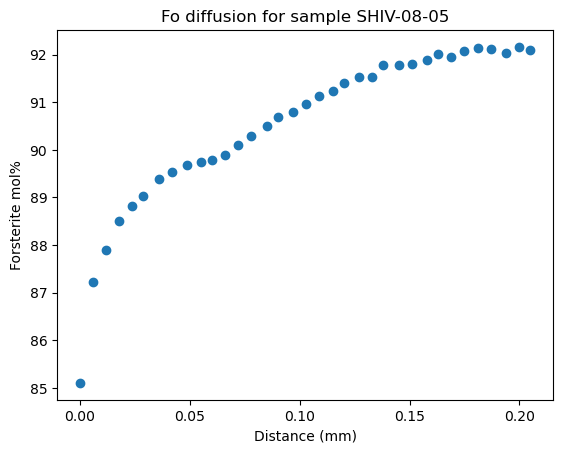

In [514]:
x = ['Distance (mm)']
y1 = ['Fo (mol%)']
y2 = ['NiO (wt%)']

plt.scatter(data['Distance (mm)'], data['Fo (mol%)'])

plt.xlabel('Distance (mm)')
plt.ylabel('Forsterite mol%')
plt.title('Fo diffusion for sample SHIV-08-05')

Text(0.5, 1.0, 'NiO diffusion for sample SHIV-08-05')

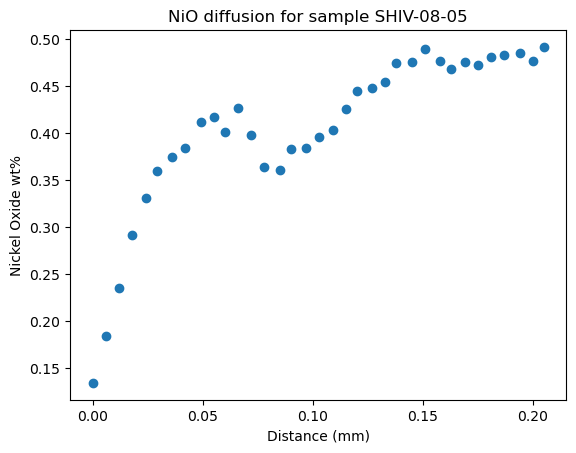

In [515]:
plt.scatter(data['Distance (mm)'], data['NiO (wt%)'])
plt.xlabel('Distance (mm)')
plt.ylabel('Nickel Oxide wt%')
plt.title('NiO diffusion for sample SHIV-08-05')

In [516]:
df_clean = data[['Distance (mm)', 'NiO (wt%)']].apply(pd.to_numeric, errors='coerce').dropna()

x = df_clean['Distance (mm)'].values * 1e-3
y = df_clean['NiO (wt%)'].values

In [517]:
x = ['Distance (mm)']
y = ['NiO (wt%)']


In [518]:
x = pd.to_numeric(df["Distance (mm)"], errors="coerce") * 1e-3
y = pd.to_numeric(df["NiO (wt%)"], errors="coerce")

mask = (~x.isna()) & (~y.isna())
x = x[mask].values
y = y[mask].values

In [519]:
df_clean = df[["Distance (mm)", "NiO (wt%)"]].apply(pd.to_numeric, errors="coerce").dropna()

x = df_clean["Distance (mm)"].values * 1e-3
y = df_clean["NiO (wt%)"].values

mask = (x > 0) & (y > 0)

x = x[mask]
y = y[mask]
assert len(x) == len(y)

x = data['Distance (mm)'].values * 1e-3  # convert mm → m
y = data['NiO (wt%)'].values

print(x.shape, y.shape)

(35,) (35,)


In [520]:
p0 = [min(y), max(y), 1e-10]  # initial guesses for C0, Cs, Dt

popt, pcov = curve_fit(diffusion_model, x, y, p0=p0, maxfev=5000)

C0, Cs, Dt = popt  # now C0, Cs, Dt exist
print("C0 =", C0)
print("Cs =", Cs)
print("Dt =", Dt)

C0 = 0.15739071613517067
Cs = 0.4472031450208966
Dt = 6.011542390762779e-10


In [521]:
#nickel oxide

from scipy.special import erf

def diffusion_model(x, C0, Cs, Dt):
    return C0 + (Cs-C0) * erf(x / (2 * np.sqrt(Dt)))

from scipy.optimize import curve_fit

t = 9600 # 400 days based on the document
def model_fit(x, C0, Cs, Dt):
    return diffusion_model(x, C0, Cs, Dt)

popt, pcov = curve_fit(diffusion_model, x, y, maxfev=5000)

initial_guess = [min(C), max(C), 1e-14]

params, covariance = curve_fit(model_fit, x, C, p0=initial_guess)

C0_fit, Cs_fit, D_fit = params
print("Fitted diffusion coefficient D =", D_fit, "m^2/s")


ValueError: operands could not be broadcast together with shapes (35,) (5,) 

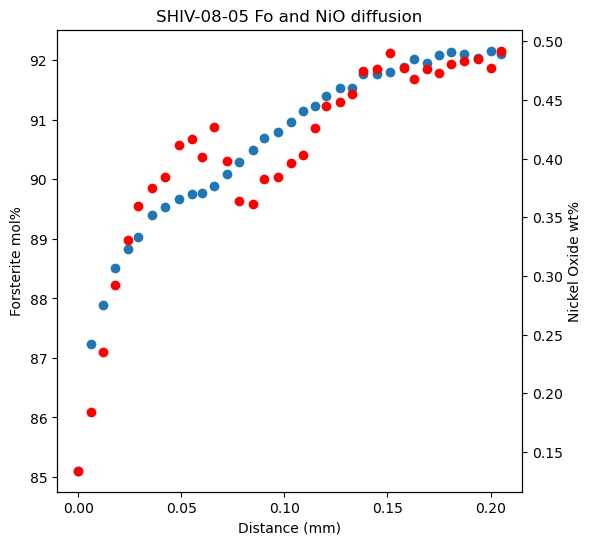

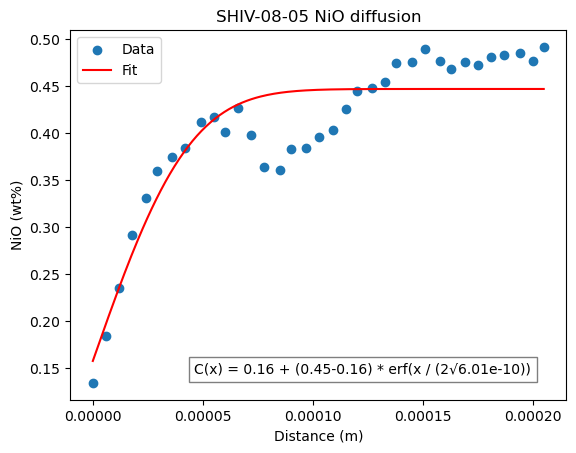

In [522]:
fig, ax1 = plt.subplots(figsize=(6,6))
ax1.scatter(data['Distance (mm)'], data['Fo (mol%)'])
plt.xlabel('Distance (mm)')
plt.ylabel('Forsterite mol%')
ax.plot(data['Distance (mm)'], data['Fo (mol%)'], color='blue', linestyle='--', label='Connecting Line')

ax2=ax1.twinx()
ax2.scatter(data['Distance (mm)'], data['NiO (wt%)'], color='r')
plt.ylabel('Nickel Oxide wt%')
ax.plot(data['Distance (mm)'], data['Fo (mol%)'], color='red', linestyle='--', label='Connecting Line')

plt.title('SHIV-08-05 Fo and NiO diffusion')
ax.legend()
plt.show()

x_fit = np.linspace(min(x), max(x), 200)
y_fit = diffusion_model(x_fit, C0, Cs, Dt)
equation_text = f"C(x) = {C0:.2f} + ({Cs:.2f}-{C0:.2f}) * erf(x / (2√{Dt:.2e}))"
plt.text(0.25, 0.1, equation_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.title('SHIV-08-05 NiO diffusion')
plt.scatter(x, y, label="Data")
plt.plot(x_fit, y_fit, color='red', label="Fit")
plt.xlabel("Distance (m)")
plt.ylabel("NiO (wt%)")
plt.legend()
plt.show()


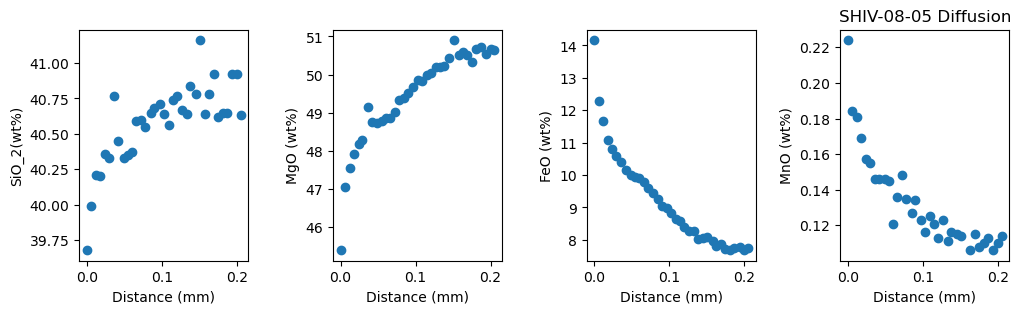

In [511]:
parascatter(df0, ['Distance (mm)'],['SiO_2(wt%)','MgO (wt%)','FeO (wt%)','MnO (wt%)'])
plt.title('SHIV-08-05 Diffusion')

plt.subplots_adjust(hspace=0.8)
plt.subplots_adjust(wspace=0.5)